In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import scipy.stats  as stats


In [7]:
df = pd.read_csv('train.csv' , usecols=['Age' , 'Fare' , 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [12]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\Arjun Kaushik\AppData\Local\Temp\ipykernel_35000\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [13]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [14]:
x = df.iloc[:,1:3]
y = df.iloc[:,0]

In [15]:
x_train , X_test , y_train , y_test = train_test_split(x , y ,test_size=0.2 , random_state=42)

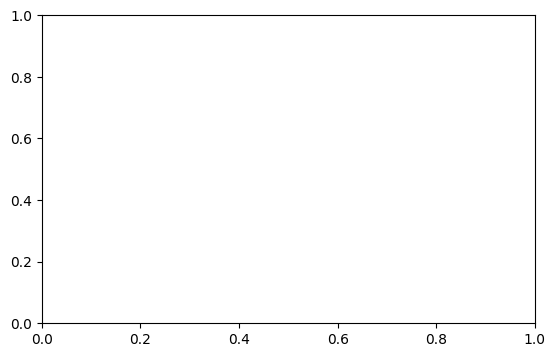

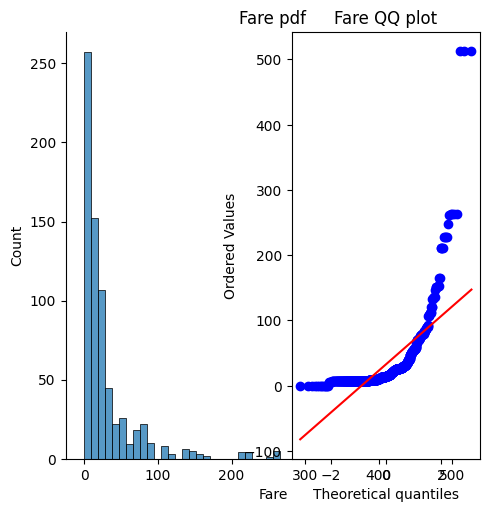

In [21]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.displot(x_train['Fare'])
plt.title('Fare pdf')
plt.subplot(122)
stats.probplot(x_train['Fare'] , dist='norm' , plot=plt)
plt.title('Fare QQ plot')
plt.show()

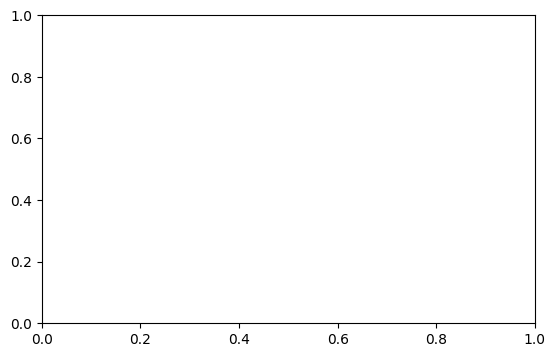

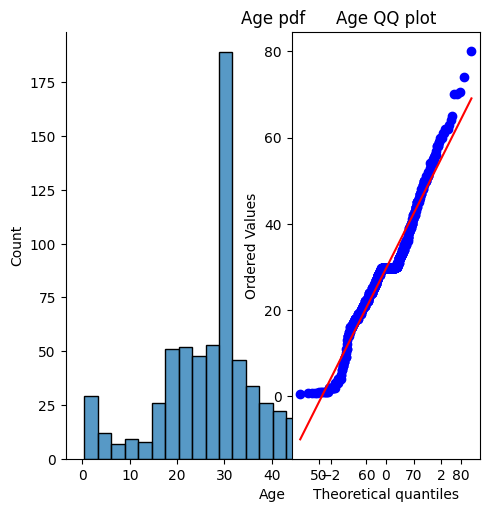

In [20]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.displot(x_train['Age'])
plt.title('Age pdf')
plt.subplot(122)
stats.probplot(x_train['Age'] , dist='norm' , plot=plt)
plt.title('Age QQ plot')
plt.show()

In [ ]:
clf1 = DecisionTreeClassifier()
clf2 = LogisticRegression()

In [32]:
clf1.fit(x_train,y_train)
clf2.fit(x_train,y_train)
y_pred = clf1.predict(X_test)
y_pred1 = clf2.predict(X_test)
print('Accuracy DT' , accuracy_score(y_test , y_pred))
print('Accuracy LR' ,   accuracy_score(y_test , y_pred1))

Accuracy DT 0.6536312849162011
Accuracy LR 0.6480446927374302


In [ ]:
trf = FunctionTransformer(func=np.log1p)

In [ ]:
x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.transform(X_test)

In [36]:
clf1.fit(x_train_transformed , y_train)
clf2.fit(x_train_transformed , y_train)

y_pred = clf1.predict(x_test_transformed)
y_pred1 = clf2.predict(x_test_transformed)
print('Accuracy DT' , accuracy_score(y_test,y_pred))
print('Accuracy LR' , accuracy_score(y_test,y_pred1))

Accuracy DT 0.6759776536312849
Accuracy LR 0.6815642458100558
